# Домашнее задание №6

**Классификация облаков**

**Студент** Сизиков Константин Александрович

**Цель:**
Неглубокие облака играют огромную роль в определении климата Земли, но их трудно распознать и классифицировать в климатических моделях. Классифицируя различные типы организации облаков, исследователи из Института Макса Планка надеются улучшить наше физическое понимание этих облаков, что, в свою очередь, поможет нам построить более совершенные климатические модели.

Существует множество способов организации облаков, но границы между различными формами организации нечеткие. Это затрудняет построение традиционных алгоритмов, основанных на правилах, для разделения облачных характеристик. Однако человеческий глаз отлично справляется с обнаружением особенностей - например, облаков, похожих на цветы.

В этом задании вам предстоит построить модель для классификации моделей организации облаков на спутниковых снимках. В случае успеха вы поможете ученым лучше понять, как облака будут определять наш будущий климат.


**Описание/Пошаговая инструкция выполнения домашнего задания:**
 - сформировать нейронную сверточную сеть;
 - обучить сеть на представленных данных;
 - оценить качество модели. В качестве критерия используйте Dice coefficient.
 - датасет для обучения модели: https://drive.google.com/file/d/1leoj71B_D_paBLC1uP5EKcnR5lJFPovn/view

**Сравниваются две модели:**

1. **SimpleCNN** — свёрточная сеть, обучаемая с нуля, без
   предобученных весов;
2. **ResNet18** (transfer learning) — backbone, предобученный на ImageNet, с
   заменённой полносвязной головой под 4 класса, дообучаемый полностью
   (fine-tuning).

Для обеих моделей используется цикл обучения с ранней
остановкой по Dice coefficient на валидации, что позволяет честно сравнить
качество «сеть с нуля» vs «перенос обучения».

In [1]:
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3090


In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "understanding_cloud_organization"
IMG_DIR = DATA_DIR / "train_images"
CSV_PATH = DATA_DIR / "train.csv"

CLASSES = ["Fish", "Flower", "Gravel", "Sugar"]
COLORS = {"Fish": "#0072B2", "Flower": "#E69F00", "Gravel": "#009E73", "Sugar": "#D55E00"}
NUM_CLASSES = len(CLASSES)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

assert DATA_DIR.exists(), f"Не найдена папка с данными: {DATA_DIR}"
print("Train images dir:", IMG_DIR)

Train images dir: /home/ubuntu/projects/ml/machine_learning_professional/hw_06/understanding_cloud_organization/train_images


## 1. Подготовка данных

Исходный `train.csv` размечен построчно: одна строка — одна
пара (изображение, класс) с RLE-маской (или `NaN`, если класса на снимке
нет). Разворачиваем это в таблицу `labels_df`: одна строка на изображение,
колонки — бинарные метки наличия каждого из 4 классов.

In [3]:
df = pd.read_csv(CSV_PATH)
df[["Image", "Label"]] = df["Image_Label"].str.split("_", expand=True)
df["HasMask"] = df["EncodedPixels"].notna()

labels_df = df.pivot(index="Image", columns="Label", values="HasMask").fillna(False)
labels_df = labels_df[CLASSES].astype(int)

print(f"Всего снимков: {len(labels_df)}")
labels_df.head()

Всего снимков: 5546


Label,Fish,Flower,Gravel,Sugar
Image,,,,
0011165.jpg,1,1,0,0
002be4f.jpg,1,1,0,1
0031ae9.jpg,1,1,0,1
0035239.jpg,0,1,1,0
003994e.jpg,1,0,1,1


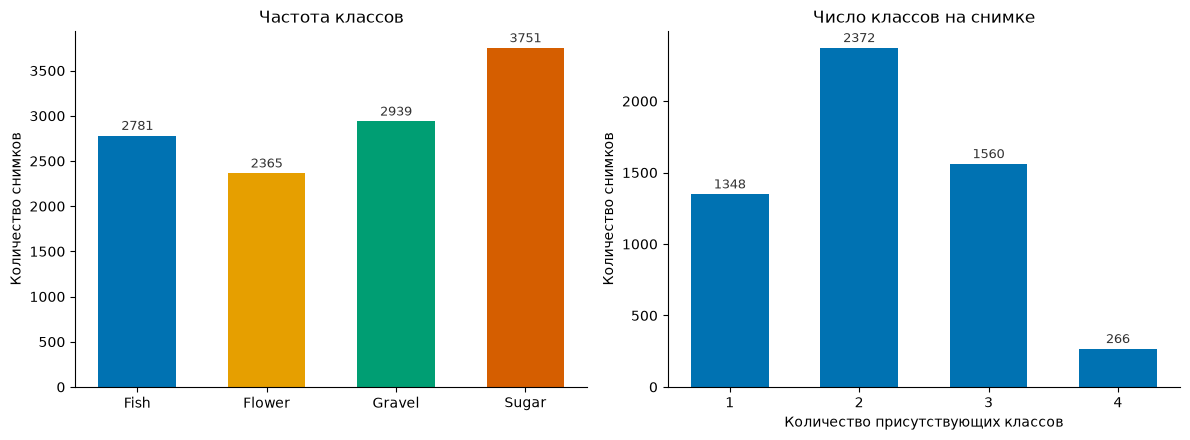

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

class_counts = labels_df.sum().reindex(CLASSES)
axes[0].bar(class_counts.index, class_counts.values,
            color=[COLORS[c] for c in CLASSES], width=0.6)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", va="bottom", fontsize=9, color="#333333")
axes[0].set_title("Частота классов")
axes[0].set_ylabel("Количество снимков")
axes[0].spines[["top", "right"]].set_visible(False)

label_counts = labels_df.sum(axis=1).value_counts().sort_index()
axes[1].bar(label_counts.index.astype(str), label_counts.values, color="#0072B2", width=0.6)
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 20, str(v), ha="center", va="bottom", fontsize=9, color="#333333")
axes[1].set_title("Число классов на снимке")
axes[1].set_xlabel("Количество присутствующих классов")
axes[1].set_ylabel("Количество снимков")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Быстрая проверка на исходных данных: декодируем RLE-маски и отрисуем их
контуром на нескольких снимках, чтобы убедиться, что метки соответствуют
содержимому изображений.

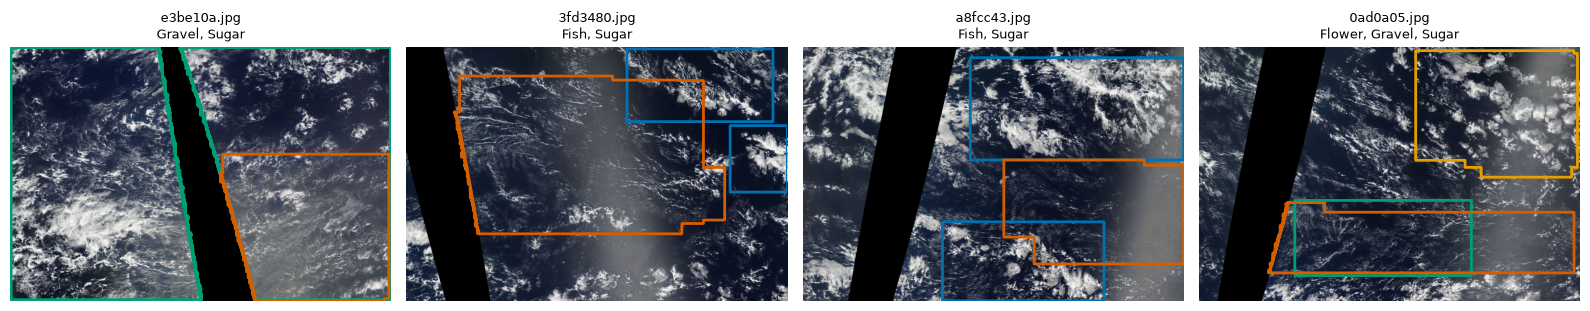

In [5]:
def rle_decode(mask_rle, shape=(1400, 2100)):
    '''Декодирует RLE-строку соревнования в бинарную маску (height, width).'''
    if pd.isna(mask_rle):
        return np.zeros(shape, dtype=np.uint8)
    s = mask_rle.split()
    starts = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    ends = starts + lengths
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        mask[lo:hi] = 1
    return mask.reshape(shape, order="F")


def show_sample(image_id, ax):
    img = Image.open(IMG_DIR / image_id)
    ax.imshow(img)
    present = []
    for _, row in df[df["Image"] == image_id].iterrows():
        if row["HasMask"]:
            mask = rle_decode(row["EncodedPixels"])
            ax.contour(mask, levels=[0.5], colors=[COLORS[row["Label"]]], linewidths=2)
            present.append(row["Label"])
    ax.set_title(f"{image_id}\n{', '.join(present)}", fontsize=9)
    ax.axis("off")


sample_ids = np.random.RandomState(SEED).choice(labels_df.index.values, size=4, replace=False)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for image_id, ax in zip(sample_ids, axes):
    show_sample(image_id, ax)
plt.tight_layout()
plt.show()

## 2. Train / validation split

Разбиваем изображения на train/val.

train: 4714 снимков, val: 832 снимков


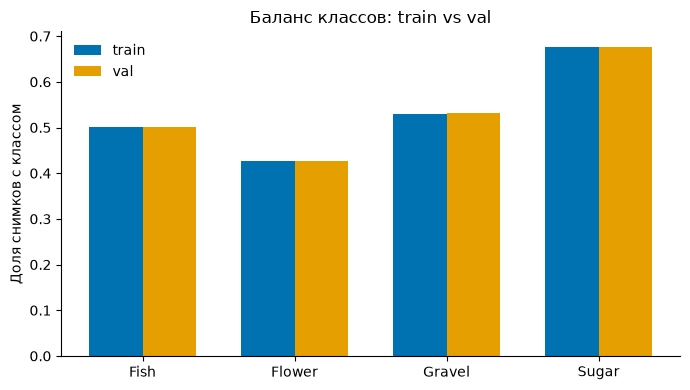

In [6]:
combo_key = labels_df.apply(lambda r: "".join(r.astype(str)), axis=1)

train_ids, val_ids = train_test_split(
    labels_df.index.values,
    test_size=0.15,
    random_state=SEED,
    stratify=combo_key,
)
print(f"train: {len(train_ids)} снимков, val: {len(val_ids)} снимков")

train_labels = labels_df.loc[train_ids]
val_labels = labels_df.loc[val_ids]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(CLASSES))
width = 0.35
ax.bar(x - width / 2, train_labels[CLASSES].mean(), width, label="train", color="#0072B2")
ax.bar(x + width / 2, val_labels[CLASSES].mean(), width, label="val", color="#E69F00")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Доля снимков с классом")
ax.set_title("Баланс классов: train vs val")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Dataset и DataLoader

Аугментация для train — случайные отражения и лёгкий color jitter (облачные
текстуры не имеют выделенной ориентации, поэтому вертикальный/горизонтальный
flip допустимы). Нормализация — статистики ImageNet, так как одна из моделей
использует предобученный на ImageNet backbone.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class CloudsDataset(Dataset):
    def __init__(self, image_ids, labels_df, img_dir, transform):
        self.image_ids = list(image_ids)
        self.labels_df = labels_df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img = Image.open(self.img_dir / image_id).convert("RGB")
        img = self.transform(img)
        target = torch.tensor(self.labels_df.loc[image_id].values, dtype=torch.float32)
        return img, target


train_ds = CloudsDataset(train_ids, train_labels, IMG_DIR, train_tf)
val_ds = CloudsDataset(val_ids, val_labels, IMG_DIR, val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

imgs, tgts = next(iter(train_loader))
print("batch images:", imgs.shape, "batch targets:", tgts.shape)

batch images: torch.Size([32, 3, 224, 224]) batch targets: torch.Size([32, 4])


## 4. Модель 1: SimpleCNN — свёрточная сеть с нуля

Небольшая сеть без предобученных весов: 5 свёрточных блоков
(`Conv → BatchNorm → ReLU`, дважды на блок) с уменьшением пространственного
размера `MaxPool2d` между блоками, затем `AdaptiveAvgPool2d` и полносвязная
голова с `Dropout` под 4 класса. Обучается полностью с нуля без переноса обучения.

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)


def build_simple_cnn():
    return SimpleCNN().to(DEVICE)


_test_model = build_simple_cnn()
_test_out = _test_model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print("SimpleCNN sanity check output shape:", _test_out.shape)
del _test_model, _test_out

SimpleCNN sanity check output shape: torch.Size([2, 4])


## 5. Модель 2: ResNet18 — перенос обучения (transfer learning)

Backbone `resnet18`, предобученный на ImageNet, с заменённым последним
`Linear`-слоем (`fc`) под 4 класса. Дообучаем **все** веса сети (полный
fine-tuning), а не только голову — при небольшом `lr` это даёт лучшее
качество, чем заморозка backbone, за счёт адаптации под текстуры облаков со спутника.

In [9]:
def build_resnet18(num_classes=NUM_CLASSES):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)


_test_model = build_resnet18()
_test_out = _test_model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print("ResNet18 sanity check output shape:", _test_out.shape)
del _test_model, _test_out

ResNet18 sanity check output shape: torch.Size([2, 4])


## 6. Метрика: Dice coefficient

Считаем две версии:
- **sample-wise** (усреднённая по снимкам) — используется как основная
  метрика и критерий ранней остановки;
- **per-class** (усреднённая по классам) — для финального сравнения моделей.

In [10]:
def dice_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    '''Средний по батчу sample-wise Dice coefficient.'''
    preds = (torch.sigmoid(logits) > threshold).float()
    intersection = (preds * targets).sum(dim=1)
    denom = preds.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (denom + eps)
    return dice.mean().item()


def per_class_dice(all_logits, all_targets, threshold=0.5, eps=1e-7):
    '''Dice coefficient отдельно для каждого класса (по всей выборке).'''
    preds = (torch.sigmoid(all_logits) > threshold).float()
    tp = (preds * all_targets).sum(dim=0)
    denom = preds.sum(dim=0) + all_targets.sum(dim=0)
    dice = (2 * tp + eps) / (denom + eps)
    return {c: d.item() for c, d in zip(CLASSES, dice)}

## 7. Цикл обучения с ранней остановкой по Dice

Цикл обучения на чистом PyTorch: `BCEWithLogitsLoss` (multi-label)
+ `AdamW` + косинусный scheduler. После каждой эпохи считается Dice
coefficient на валидации; если метрика не улучшается `patience` эпох подряд —
обучение останавливается, а модели возвращаются веса **лучшей по Dice**
эпохи (не последней).

In [11]:
def train_model(model, train_loader, val_loader, name,
                 max_epochs=30, patience=5, lr=1e-3, weight_decay=1e-4):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    history = {"train_loss": [], "val_loss": [], "val_dice": []}
    best_dice, best_epoch, best_state = -1.0, -1, None
    epochs_no_improve = 0
    start = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, tgts in train_loader:
            imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, tgts)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        scheduler.step()

        model.eval()
        val_running_loss, val_dice_sum, n_val = 0.0, 0.0, 0
        with torch.no_grad():
            for imgs, tgts in val_loader:
                imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
                logits = model(imgs)
                loss = criterion(logits, tgts)
                val_running_loss += loss.item() * imgs.size(0)
                val_dice_sum += dice_from_logits(logits, tgts) * imgs.size(0)
                n_val += imgs.size(0)
        val_loss = val_running_loss / n_val
        val_dice = val_dice_sum / n_val

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)

        improved = val_dice > best_dice
        if improved:
            best_dice, best_epoch = val_dice, epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        marker = " *" if improved else ""
        print(f"[{name}] epoch {epoch:02d}/{max_epochs} "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
              f"val_dice={val_dice:.4f}{marker}")

        if epochs_no_improve >= patience:
            print(f"[{name}] early stopping: Dice не улучшается {patience} эпох подряд "
                  f"(лучшая эпоха {best_epoch}, val_dice={best_dice:.4f})")
            break

    model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    history["best_dice"] = best_dice
    history["n_params"] = sum(p.numel() for p in model.parameters())
    history["train_time_sec"] = time.time() - start
    return model, history

## 8. Обучение модели 1 — SimpleCNN (с нуля)

Больший `lr` и больше эпох, т.к. сеть без предобученных весов сходится
медленнее.

In [12]:
torch.manual_seed(SEED)
model_cnn = build_simple_cnn()
model_cnn, history_cnn = train_model(
    model_cnn, train_loader, val_loader,
    name="SimpleCNN", max_epochs=30, patience=6, lr=1e-3,
)

[SimpleCNN] epoch 01/30 train_loss=0.6039 val_loss=0.7373 val_dice=0.6208 *


[SimpleCNN] epoch 02/30 train_loss=0.5701 val_loss=0.5981 val_dice=0.6861 *


[SimpleCNN] epoch 03/30 train_loss=0.5605 val_loss=0.6831 val_dice=0.6759


[SimpleCNN] epoch 04/30 train_loss=0.5585 val_loss=0.5309 val_dice=0.7327 *


[SimpleCNN] epoch 05/30 train_loss=0.5513 val_loss=0.5824 val_dice=0.7140


...

[SimpleCNN] epoch 12/30 train_loss=0.5204 val_loss=0.6319 val_dice=0.6548


[SimpleCNN] epoch 13/30 train_loss=0.5144 val_loss=0.6539 val_dice=0.6816


[SimpleCNN] epoch 14/30 train_loss=0.5152 val_loss=0.5620 val_dice=0.7256


[SimpleCNN] epoch 15/30 train_loss=0.5115 val_loss=0.5152 val_dice=0.7369


[SimpleCNN] epoch 16/30 train_loss=0.5110 val_loss=0.5144 val_dice=0.7417
[SimpleCNN] early stopping: Dice не улучшается 6 эпох подряд (лучшая эпоха 10, val_dice=0.7427)


## 9. Обучение модели 2 — ResNet18 (transfer learning)

Те же данные, та же аугментация, тот же алгоритм обучения.
Отличие в архитектуре и стартовых весах. Меньший `lr`, так как backbone уже
предобучен и его не нужно «ломать» большими градиентными шагами.

In [13]:
torch.manual_seed(SEED)
model_resnet = build_resnet18()
model_resnet, history_resnet = train_model(
    model_resnet, train_loader, val_loader,
    name="ResNet18", max_epochs=30, patience=6, lr=1e-4,
)

[ResNet18] epoch 01/30 train_loss=0.5600 val_loss=0.5256 val_dice=0.7418 *


[ResNet18] epoch 02/30 train_loss=0.5012 val_loss=0.5163 val_dice=0.7360


[ResNet18] epoch 03/30 train_loss=0.4687 val_loss=0.5065 val_dice=0.7542 *


[ResNet18] epoch 04/30 train_loss=0.4394 val_loss=0.5146 val_dice=0.7471


[ResNet18] epoch 05/30 train_loss=0.4011 val_loss=0.5413 val_dice=0.7452


[ResNet18] epoch 06/30 train_loss=0.3676 val_loss=0.5674 val_dice=0.7413


[ResNet18] epoch 07/30 train_loss=0.3278 val_loss=0.5817 val_dice=0.7292


[ResNet18] epoch 08/30 train_loss=0.2869 val_loss=0.5960 val_dice=0.7367


[ResNet18] epoch 09/30 train_loss=0.2366 val_loss=0.6267 val_dice=0.7496
[ResNet18] early stopping: Dice не улучшается 6 эпох подряд (лучшая эпоха 3, val_dice=0.7542)


## 10. Графики обучения

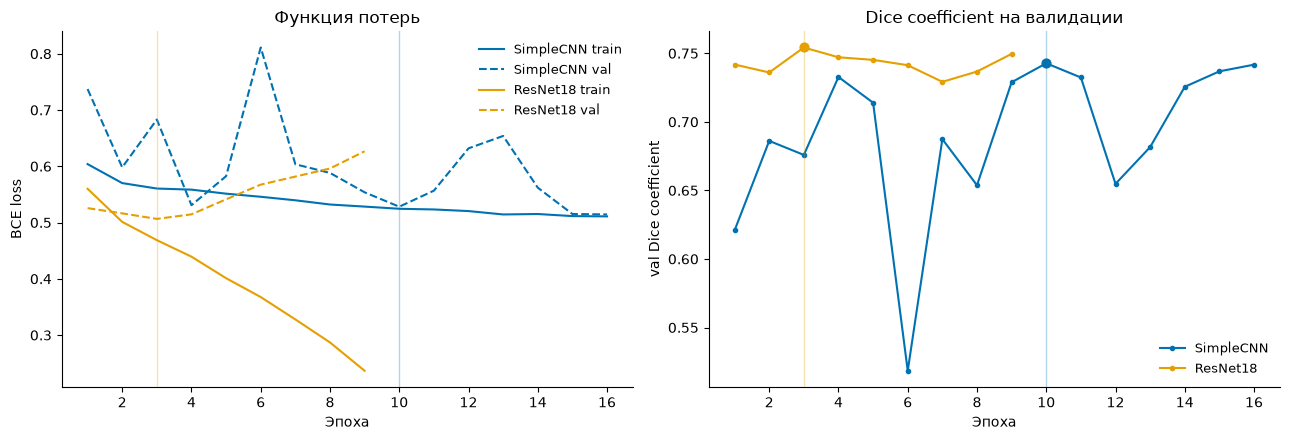

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_cnn = range(1, len(history_cnn["train_loss"]) + 1)
epochs_resnet = range(1, len(history_resnet["train_loss"]) + 1)

axes[0].plot(epochs_cnn, history_cnn["train_loss"], color="#0072B2", label="SimpleCNN train")
axes[0].plot(epochs_cnn, history_cnn["val_loss"], color="#0072B2", linestyle="--", label="SimpleCNN val")
axes[0].plot(epochs_resnet, history_resnet["train_loss"], color="#E69F00", label="ResNet18 train")
axes[0].plot(epochs_resnet, history_resnet["val_loss"], color="#E69F00", linestyle="--", label="ResNet18 val")
axes[0].axvline(history_cnn["best_epoch"], color="#0072B2", alpha=0.3, linewidth=1)
axes[0].axvline(history_resnet["best_epoch"], color="#E69F00", alpha=0.3, linewidth=1)
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Функция потерь")
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(epochs_cnn, history_cnn["val_dice"], color="#0072B2", marker="o", markersize=3, label="SimpleCNN")
axes[1].plot(epochs_resnet, history_resnet["val_dice"], color="#E69F00", marker="o", markersize=3, label="ResNet18")
axes[1].axvline(history_cnn["best_epoch"], color="#0072B2", alpha=0.3, linewidth=1)
axes[1].axvline(history_resnet["best_epoch"], color="#E69F00", alpha=0.3, linewidth=1)
axes[1].scatter([history_cnn["best_epoch"]], [history_cnn["best_dice"]], color="#0072B2", zorder=5, s=40)
axes[1].scatter([history_resnet["best_epoch"]], [history_resnet["best_dice"]], color="#E69F00", zorder=5, s=40)
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("val Dice coefficient")
axes[1].set_title("Dice coefficient на валидации")
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 11. Сравнение качества моделей

In [15]:
@torch.no_grad()
def collect_val_predictions(model):
    model.eval()
    all_logits, all_targets = [], []
    for imgs, tgts in val_loader:
        logits = model(imgs.to(DEVICE)).cpu()
        all_logits.append(logits)
        all_targets.append(tgts)
    return torch.cat(all_logits), torch.cat(all_targets)


logits_cnn, targets_cnn = collect_val_predictions(model_cnn)
logits_resnet, targets_resnet = collect_val_predictions(model_resnet)

per_class_cnn = per_class_dice(logits_cnn, targets_cnn)
per_class_resnet = per_class_dice(logits_resnet, targets_resnet)

summary = pd.DataFrame({
    "model": ["SimpleCNN (с нуля)", "ResNet18 (transfer learning)"],
    "params_M": [history_cnn["n_params"] / 1e6, history_resnet["n_params"] / 1e6],
    "best_epoch": [history_cnn["best_epoch"], history_resnet["best_epoch"]],
    "val_dice_samplewise": [history_cnn["best_dice"], history_resnet["best_dice"]],
    "val_dice_mean_per_class": [
        np.mean(list(per_class_cnn.values())),
        np.mean(list(per_class_resnet.values())),
    ],
    "train_time_min": [history_cnn["train_time_sec"] / 60, history_resnet["train_time_sec"] / 60],
})
summary

,model,params_M,best_epoch,val_dice_samplewise,val_dice_mean_per_class,train_time_min
0,SimpleCNN (с нуля),2.388772,10,0.742737,0.746648,8.941949
1,ResNet18 (transfer learning),11.178564,3,0.754247,0.759092,5.254420


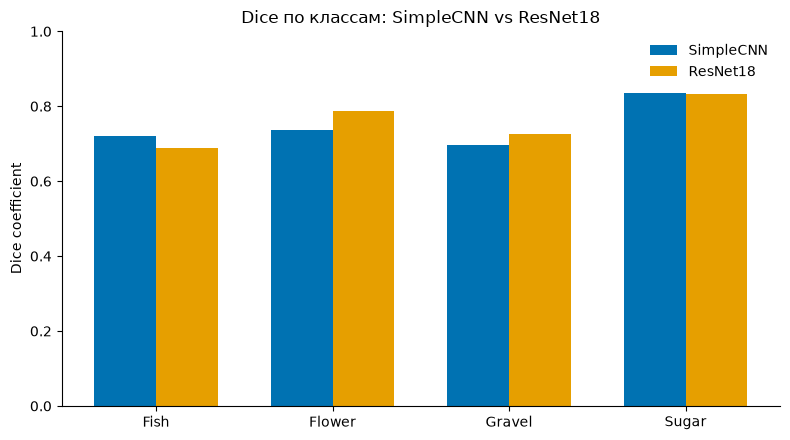

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(CLASSES))
width = 0.35
ax.bar(x - width / 2, [per_class_cnn[c] for c in CLASSES], width, label="SimpleCNN", color="#0072B2")
ax.bar(x + width / 2, [per_class_resnet[c] for c in CLASSES], width, label="ResNet18", color="#E69F00")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Dice coefficient")
ax.set_ylim(0, 1)
ax.set_title("Dice по классам: SimpleCNN vs ResNet18")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 12. Проверка на валидационных снимках

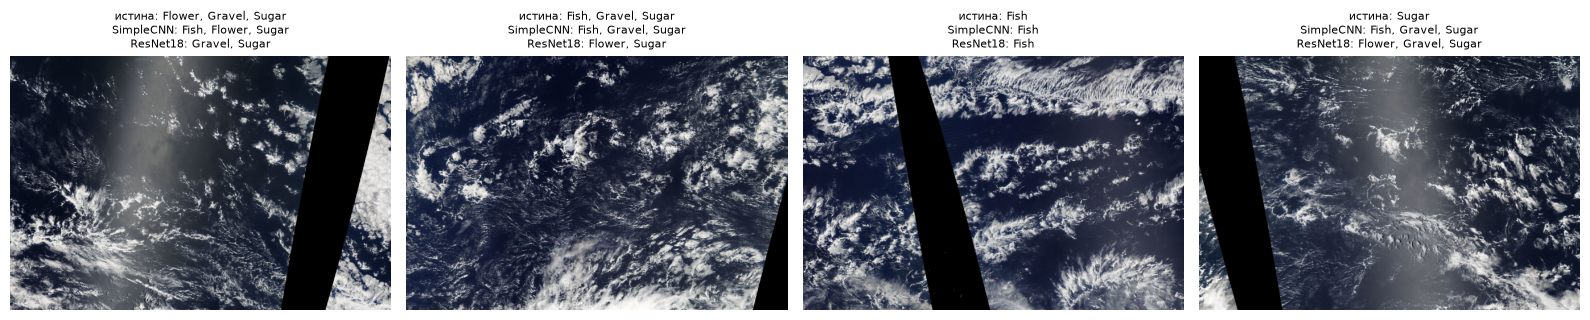

In [17]:
@torch.no_grad()
def predict_labels(model, image_id, threshold=0.5):
    img = Image.open(IMG_DIR / image_id).convert("RGB")
    x = val_tf(img).unsqueeze(0).to(DEVICE)
    model.eval()
    probs = torch.sigmoid(model(x)).cpu().numpy()[0]
    pred = [c for c, p in zip(CLASSES, probs) if p > threshold]
    return pred, probs


sample_val_ids = np.random.RandomState(SEED).choice(val_ids, size=4, replace=False)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for image_id, ax in zip(sample_val_ids, axes):
    pred_cnn, _ = predict_labels(model_cnn, image_id)
    pred_resnet, _ = predict_labels(model_resnet, image_id)
    true = [c for c in CLASSES if labels_df.loc[image_id, c] == 1]
    img = Image.open(IMG_DIR / image_id)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"истина: {', '.join(true)}\n"
        f"SimpleCNN: {', '.join(pred_cnn) if pred_cnn else '—'}\n"
        f"ResNet18: {', '.join(pred_resnet) if pred_resnet else '—'}",
        fontsize=8,
    )
plt.tight_layout()
plt.show()

## 13. Выводы

**Итоги сравнения моделей**

**SimpleCNN** (с нуля): 2.4M параметров, best val Dice = 0.7427 (эпоха 10), обучение 8.9 мин

**ResNet18** (transfer learning): 11.2M параметров, best val Dice = 0.7542 (эпоха 3), обучение 5.3 мин

Лучшее качество по Dice coefficient показала модель ResNet18 (transfer learning) (разница: 0.0115).

ResNet18 стартует с признаков, предобученных на ImageNet, поэтому даже на относительно небольшой выборке (~5.5к снимков) он, как правило, обучается быстрее и увереннее находит текстурные признаки типов организации облаков, чем SimpleCNN, обучаемая с нуля. SimpleCNN — полностью самостоятельная архитектура без переноса знаний, и её качество ограничено объёмом обучающей выборки и глубиной сети; она может служить базовой линией (baseline), относительно которой измеряется выигрыш от transfer learning.

## 14. Сохранение обученных моделей

In [19]:
SAVE_DIR = ROOT / "models"
SAVE_DIR.mkdir(exist_ok=True)

torch.save({
    "model_state_dict": model_cnn.state_dict(),
    "classes": CLASSES,
    "img_size": IMG_SIZE,
    "val_dice": history_cnn["best_dice"],
    "best_epoch": history_cnn["best_epoch"],
}, SAVE_DIR / "pytorch_simplecnn_multilabel_best.pt")

torch.save({
    "model_state_dict": model_resnet.state_dict(),
    "classes": CLASSES,
    "img_size": IMG_SIZE,
    "val_dice": history_resnet["best_dice"],
    "best_epoch": history_resnet["best_epoch"],
}, SAVE_DIR / "pytorch_resnet18_multilabel_best.pt")

print("Сохранено:")
print(f"  {SAVE_DIR / 'pytorch_simplecnn_multilabel_best.pt'}  (val Dice={history_cnn['best_dice']:.4f})")
print(f"  {SAVE_DIR / 'pytorch_resnet18_multilabel_best.pt'}  (val Dice={history_resnet['best_dice']:.4f})")

Сохранено:
  /home/ubuntu/projects/ml/machine_learning_professional/hw_06/models/pytorch_simplecnn_multilabel_best.pt  (val Dice=0.7427)
  /home/ubuntu/projects/ml/machine_learning_professional/hw_06/models/pytorch_resnet18_multilabel_best.pt  (val Dice=0.7542)
